## Locomotion Analysis Settings (Read First)

This notebook computes SS/CS rate and synchrony modulation around movement onset and versus running velocity.

Parameter annotation:
- Movement detection: velocity threshold, minimum rest duration, minimum run duration
- Movement-onset windows: baseline and response windows (ms)
- PETH settings: window and step size (ms)
- Rate smoothing: SS and CS smoothing (ms)
- Synchrony settings: SS and CS synchrony bin sizes (ms)
- Velocity tuning: number of velocity bins

Run Cell 1 (setup), then run the settings summary cell to confirm all active parameters before running the main analysis.

In [14]:
from pathlib import Path
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

# ---- Configuration ----
# Master folder should contain both:
#   1) spike_detection/*.npz
#   2) behavior/*.csv
_project_root = Path.cwd().resolve()
if not (_project_root / 'data').exists() and (_project_root.parent / 'data').exists():
    _project_root = _project_root.parent.resolve()

MASTER_FOLDER = _project_root / 'data' / '20260327_6GrCs'
SPIKE_SUBFOLDER = 'spike_detection'
BEHAVIOR_SUBFOLDER = 'behavior'
SPIKE_GLOB = '*_analyzed.npz'
BEHAVIOR_GLOB = '*.csv'

TIME_COLUMN = 'Time_s'
VELOCITY_COLUMN = 'Smoothed_Vel_cm_s'
USE_ABS_VELOCITY = True

CONFIG = {
    'movement_threshold_cm_s': 0.3,
    'min_rest_s': 0.5,
    'min_run_s': 0.5,
    'onset_baseline_ms': (-600.0, -100.0),
    'onset_response_ms': (0.0, 500.0),
    'peth_window_ms': (-1200.0, 1200.0),
    'peth_step_ms': 20.0,
    'ss_rate_smooth_ms': 80.0,
    'cs_rate_smooth_ms': 180.0,
    'ss_sync_bin_ms': 5.0,
    'cs_sync_bin_ms': 25.0,
    'velocity_tuning_n_bins': 14,
}

CONFIG_MEANINGS = {
    'movement_threshold_cm_s': 'Velocity threshold used to detect movement onset (cm/s). Crossing from below to above can trigger an onset candidate.',
    'min_rest_s': 'Required duration before onset where velocity must remain below threshold (s). Enforces a true rest period.',
    'min_run_s': 'Required duration after onset where velocity should stay above threshold on average (s). Rejects short noise transients.',
    'onset_baseline_ms': 'Baseline window relative to movement onset (ms). Used as pre-onset reference for delta calculations.',
    'onset_response_ms': 'Response window relative to movement onset (ms). Used as post-onset activity/synchrony measurement window.',
    'peth_window_ms': 'Time range around onset for aligned traces (PETH), in ms. Example: (-1200, 1200) means 1.2 s before to 1.2 s after.',
    'peth_step_ms': 'Sampling step for onset-aligned interpolation grid (ms). Smaller step gives denser traces.',
    'ss_rate_smooth_ms': 'Gaussian smoothing width for SS rate estimation (ms). Larger values produce smoother, less noisy SS rate traces.',
    'cs_rate_smooth_ms': 'Gaussian smoothing width for CS rate estimation (ms). Usually larger than SS because CS events are sparser.',
    'ss_sync_bin_ms': 'Bin size for SS population synchrony index computation (ms). Controls temporal precision of SS synchrony.',
    'cs_sync_bin_ms': 'Bin size for CS population synchrony index computation (ms). Often wider than SS due to lower CS event rate.',
    'velocity_tuning_n_bins': 'Number of bins used to summarize rate/synchrony as a function of velocity in pooled tuning curves.',
}


def _normalize_key(x):
    return str(x).strip().lower()


def _strip_animal_prefix(session_core):
    parts = str(session_core).split('_')
    if len(parts) >= 2 and re.fullmatch(r'[A-Za-z]+\d+', parts[0]):
        return '_'.join(parts[1:])
    return str(session_core)


def session_core_from_spike(npz_path):
    stem = Path(npz_path).stem
    if stem.endswith('_analyzed'):
        stem = stem[:-9]
    return stem


def session_core_from_behavior(csv_path):
    stem = Path(csv_path).stem
    parts = stem.split('_')

    # Drop trailing date + time tokens if present.
    if len(parts) >= 3 and re.fullmatch(r'\d{8}', parts[-2]) and re.fullmatch(r'\d{6}', parts[-1]):
        stem = '_'.join(parts[:-2])

    # Behavior filenames can include an animal prefix (e.g., A41_...).
    stem = _strip_animal_prefix(stem)
    return stem


def build_session_table(master_folder):
    master_folder = Path(master_folder)
    spike_dir = master_folder / SPIKE_SUBFOLDER
    beh_dir = master_folder / BEHAVIOR_SUBFOLDER

    spike_files = sorted(spike_dir.glob(SPIKE_GLOB))
    behavior_files = sorted(beh_dir.glob(BEHAVIOR_GLOB))

    if len(spike_files) == 0:
        raise FileNotFoundError(f'No spike files found in {spike_dir}')
    if len(behavior_files) == 0:
        raise FileNotFoundError(f'No behavior files found in {beh_dir}')

    behavior_map = {}
    for b in behavior_files:
        c0 = session_core_from_behavior(b)
        c1 = _strip_animal_prefix(c0)
        behavior_map.setdefault(_normalize_key(c0), []).append(b)
        behavior_map.setdefault(_normalize_key(c1), []).append(b)

    rows = []
    for s in spike_files:
        core = session_core_from_spike(s)
        cands = behavior_map.get(_normalize_key(core), [])
        if not cands:
            cands = behavior_map.get(_normalize_key(_strip_animal_prefix(core)), [])

        rows.append({
            'session_core': core,
            'spike_npz': str(s),
            'behavior_csv': str(cands[0]) if cands else None,
            'matched': len(cands) > 0,
        })

    out = pd.DataFrame(rows)
    return out.sort_values(['matched', 'session_core'], ascending=[False, True]).reset_index(drop=True)


def load_spike_session(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    required = ['time_ms', 'spike_times_ss', 'spike_times_cs', 'cell_names']
    missing = [k for k in required if k not in d.files]
    if missing:
        raise KeyError(f'Missing keys in {npz_path}: {missing}')

    return {
        'time_ms': np.asarray(d['time_ms'], dtype=float),
        'spike_times_ss': d['spike_times_ss'],
        'spike_times_cs': d['spike_times_cs'],
        'cell_names': [str(x) for x in d['cell_names']],
    }


def load_behavior_csv(csv_path):
    beh = pd.read_csv(csv_path)
    if TIME_COLUMN not in beh.columns:
        raise KeyError(f'Missing behavior column: {TIME_COLUMN}')
    if VELOCITY_COLUMN not in beh.columns:
        raise KeyError(f'Missing behavior column: {VELOCITY_COLUMN}')

    t_s = pd.to_numeric(beh[TIME_COLUMN], errors='coerce').to_numpy(dtype=float)
    vel = pd.to_numeric(beh[VELOCITY_COLUMN], errors='coerce').to_numpy(dtype=float)

    good = np.isfinite(t_s) & np.isfinite(vel)
    t_s = t_s[good]
    vel = vel[good]
    if len(t_s) == 0:
        raise ValueError(f'No finite behavior rows in {csv_path}')

    order = np.argsort(t_s)
    t_s = t_s[order]
    vel = vel[order]
    return t_s, vel


def align_velocity_to_imaging(time_ms, behavior_t_s, behavior_vel):
    imaging_t_s = np.asarray(time_ms, dtype=float) / 1000.0
    vel = np.interp(imaging_t_s, behavior_t_s, behavior_vel, left=np.nan, right=np.nan)
    if USE_ABS_VELOCITY:
        vel = np.abs(vel)
    return vel


def detect_movement_onsets(time_s, speed_cm_s, threshold, min_rest_s, min_run_s):
    time_s = np.asarray(time_s, dtype=float)
    speed = np.asarray(speed_cm_s, dtype=float)
    if len(time_s) < 5 or len(speed) != len(time_s):
        return np.array([], dtype=int)

    dt = np.nanmedian(np.diff(time_s))
    if not np.isfinite(dt) or dt <= 0:
        return np.array([], dtype=int)

    n_rest = max(1, int(round(min_rest_s / dt)))
    n_run = max(1, int(round(min_run_s / dt)))

    moving = speed >= float(threshold)
    trans = np.where((~moving[:-1]) & (moving[1:]))[0] + 1

    good = []
    for idx in trans:
        i0 = idx - n_rest
        i1 = idx + n_run
        if i0 < 0 or i1 >= len(speed):
            continue
        if np.all(speed[i0:idx] < threshold) and np.mean(speed[idx:i1]) >= threshold:
            good.append(idx)

    return np.asarray(good, dtype=int)


def spike_rate_hz(spike_times_ms, time_ms, sigma_ms):
    t = np.asarray(time_ms, dtype=float)
    n = len(t)
    if n < 3:
        return np.full(n, np.nan)

    dt = np.nanmedian(np.diff(t))
    if not np.isfinite(dt) or dt <= 0:
        return np.full(n, np.nan)

    fs = 1000.0 / dt
    vec = np.zeros(n, dtype=float)

    st = np.asarray(spike_times_ms, dtype=float)
    st = st[np.isfinite(st)]
    if len(st):
        idx = np.searchsorted(t, st)
        idx = np.clip(idx, 0, n - 1)
        np.add.at(vec, idx, 1.0)

    sigma_samples = max(1, int(round(float(sigma_ms) / dt)))
    return gaussian_filter1d(vec, sigma=sigma_samples, mode='nearest') * fs


def population_rate_hz(spike_times_by_cell, time_ms, sigma_ms):
    traces = []
    for st in spike_times_by_cell:
        traces.append(spike_rate_hz(st, time_ms, sigma_ms))
    if len(traces) == 0:
        return np.full(len(time_ms), np.nan)
    return np.nanmean(np.vstack(traces), axis=0)


def population_sync_index(spike_times_by_cell, time_ms, bin_ms):
    t = np.asarray(time_ms, dtype=float)
    if len(t) < 3:
        return np.array([]), np.array([])

    edges = np.arange(t[0], t[-1] + float(bin_ms), float(bin_ms))
    if len(edges) < 3:
        return np.array([]), np.array([])

    counts = []
    for st in spike_times_by_cell:
        x = np.asarray(st, dtype=float)
        x = x[np.isfinite(x)]
        cnt, _ = np.histogram(x, bins=edges)
        counts.append(cnt.astype(float))

    counts = np.asarray(counts, dtype=float)
    n_cells = counts.shape[0]
    if n_cells < 2:
        centers_s = (edges[:-1] + edges[1:]) / 2000.0
        return centers_s, np.full(len(centers_s), np.nan)

    mu = np.nanmean(counts, axis=1, keepdims=True)
    sd = np.nanstd(counts, axis=1, keepdims=True)
    z = np.where(sd > 0, (counts - mu) / sd, np.nan)

    pair_series = []
    for i, j in combinations(range(n_cells), 2):
        zi = z[i]
        zj = z[j]
        pair_series.append(zi * zj)

    if len(pair_series) == 0:
        centers_s = (edges[:-1] + edges[1:]) / 2000.0
        return centers_s, np.full(len(centers_s), np.nan)

    sync = np.nanmean(np.vstack(pair_series), axis=0)
    centers_s = (edges[:-1] + edges[1:]) / 2000.0
    return centers_s, sync


def event_window_mean(signal_t_ms, signal_y, event_ms, window_ms):
    t = np.asarray(signal_t_ms, dtype=float)
    y = np.asarray(signal_y, dtype=float)
    out = []

    for ev in np.asarray(event_ms, dtype=float):
        lo = ev + float(window_ms[0])
        hi = ev + float(window_ms[1])
        m = (t >= lo) & (t < hi)
        if np.any(m):
            v = np.nanmean(y[m])
            if np.isfinite(v):
                out.append(float(v))

    return np.asarray(out, dtype=float)


def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 5:
        return np.nan
    xv = x[m]
    yv = y[m]
    if np.nanstd(xv) == 0 or np.nanstd(yv) == 0:
        return np.nan
    return float(pearsonr(xv, yv)[0])


print(f'Locomotion backbone loaded. MASTER_FOLDER={MASTER_FOLDER}')

Locomotion backbone loaded. MASTER_FOLDER=/Users/liangqiyuan/Library/CloudStorage/OneDrive-Personal/main/HKU/codes/Spike_detector/data/20260327_6GrCs


In [15]:
# ---- Analysis settings summary (run after setup) ----



settings_rows = [
    {
        'Group': 'Data paths',
        'Parameter': 'MASTER_FOLDER',
        'Value': str(MASTER_FOLDER),
        'Meaning': 'Session root containing spike_detection and behavior subfolders for one experiment/day.',
    },
    {
        'Group': 'Data paths',
        'Parameter': 'SPIKE_SUBFOLDER',
        'Value': SPIKE_SUBFOLDER,
        'Meaning': 'Subfolder under MASTER_FOLDER that stores analyzed spike NPZ files.',
    },
    {
        'Group': 'Data paths',
        'Parameter': 'BEHAVIOR_SUBFOLDER',
        'Value': BEHAVIOR_SUBFOLDER,
        'Meaning': 'Subfolder under MASTER_FOLDER that stores behavior CSV files.',
    },
    {
        'Group': 'Behavior columns',
        'Parameter': 'TIME_COLUMN',
        'Value': TIME_COLUMN,
        'Meaning': 'Behavior CSV column interpreted as behavior timeline in seconds.',
    },
    {
        'Group': 'Behavior columns',
        'Parameter': 'VELOCITY_COLUMN',
        'Value': VELOCITY_COLUMN,
        'Meaning': 'Behavior CSV column used as locomotion velocity signal.',
    },
    {
        'Group': 'Behavior columns',
        'Parameter': 'USE_ABS_VELOCITY',
        'Value': USE_ABS_VELOCITY,
        'Meaning': 'If True, uses absolute velocity magnitude so direction does not affect movement detection/modulation.',
    },
]

for key in [
    'movement_threshold_cm_s',
    'min_rest_s',
    'min_run_s',
    'onset_baseline_ms',
    'onset_response_ms',
    'peth_window_ms',
    'peth_step_ms',
    'ss_rate_smooth_ms',
    'cs_rate_smooth_ms',
    'ss_sync_bin_ms',
    'cs_sync_bin_ms',
    'velocity_tuning_n_bins',
]:
    settings_rows.append({
        'Group': 'Analysis CONFIG',
        'Parameter': key,
        'Value': CONFIG[key],
        'Meaning': CONFIG_MEANINGS[key],
    })

analysis_settings_df = pd.DataFrame(settings_rows)
print('Active analysis settings with detailed annotations:')
display(analysis_settings_df)

SETTINGS_ANNOTATION = (
    f"Vel thr={CONFIG['movement_threshold_cm_s']} cm/s | rest>={CONFIG['min_rest_s']} s | run>={CONFIG['min_run_s']} s\n"
    f"Baseline={CONFIG['onset_baseline_ms']} ms | Response={CONFIG['onset_response_ms']} ms | "
    f"PETH={CONFIG['peth_window_ms']} ms step={CONFIG['peth_step_ms']} ms\n"
    f"SS smooth={CONFIG['ss_rate_smooth_ms']} ms, CS smooth={CONFIG['cs_rate_smooth_ms']} ms | "
    f"SS bin={CONFIG['ss_sync_bin_ms']} ms, CS bin={CONFIG['cs_sync_bin_ms']} ms"
)

print('\nCompact settings annotation used for figures/reports:')
print(SETTINGS_ANNOTATION)

Active analysis settings with detailed annotations:


,Group,Parameter,Value,Meaning
0,Data paths,MASTER_FOLDER,/Users/liangqiyuan/Library/CloudStorage/OneDri...,Session root containing spike_detection and be...
1,Data paths,SPIKE_SUBFOLDER,spike_detection,Subfolder under MASTER_FOLDER that stores anal...
2,Data paths,BEHAVIOR_SUBFOLDER,behavior,Subfolder under MASTER_FOLDER that stores beha...
3,Behavior columns,TIME_COLUMN,Time_s,Behavior CSV column interpreted as behavior ti...
4,Behavior columns,VELOCITY_COLUMN,Smoothed_Vel_cm_s,Behavior CSV column used as locomotion velocit...
5,Behavior columns,USE_ABS_VELOCITY,True,"If True, uses absolute velocity magnitude so d..."
6,Analysis CONFIG,movement_threshold_cm_s,0.3,Velocity threshold used to detect movement ons...
7,Analysis CONFIG,min_rest_s,0.5,Required duration before onset where velocity ...
8,Analysis CONFIG,min_run_s,0.5,Required duration after onset where velocity s...
9,Analysis CONFIG,onset_baseline_ms,"(-600.0, -100.0)",Baseline window relative to movement onset (ms...



Compact settings annotation used for figures/reports:
Vel thr=0.3 cm/s | rest>=0.5 s | run>=0.5 s
Baseline=(-600.0, -100.0) ms | Response=(0.0, 500.0) ms | PETH=(-1200.0, 1200.0) ms step=20.0 ms
SS smooth=80.0 ms, CS smooth=180.0 ms | SS bin=5.0 ms, CS bin=25.0 ms


Cell 4 runtime settings:
  downsample_target_points_per_session: 3000
  speed_bin_method: quantile
  speed_bin_count: 14
  speed_bin_max_speed_percentile: 99
  speed_bin_min_samples: 200
  speed_curve_smooth_bins: 3

Total spike sessions: 47
Matched behavior files: 47


,session_core,spike_npz,behavior_csv,matched
0,6GrC_puff_1,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True
1,6GrC_puff_10,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True
2,6GrC_puff_11,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True
3,6GrC_puff_12,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True
4,6GrC_puff_13,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True
5,6GrC_puff_14,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True
6,6GrC_puff_15,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True
7,6GrC_puff_16,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True
8,6GrC_puff_17,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True
9,6GrC_puff_18,/Users/liangqiyuan/Library/CloudStorage/OneDri...,/Users/liangqiyuan/Library/CloudStorage/OneDri...,True



Analysis settings:
Vel thr=0.3 cm/s | rest>=0.5 s | run>=0.5 s
Baseline=(-600.0, -100.0) ms | Response=(0.0, 500.0) ms | PETH=(-1200.0, 1200.0) ms step=20.0 ms
SS smooth=80.0 ms, CS smooth=180.0 ms | SS bin=5.0 ms, CS bin=25.0 ms


/var/folders/cp/q8802h992_371mtbyj83fz1h0000gn/T/ipykernel_91457/2210425239.py:259: RuntimeWarning: invalid value encountered in divide
  z = np.where(sd > 0, (counts - mu) / sd, np.nan)
/var/folders/cp/q8802h992_371mtbyj83fz1h0000gn/T/ipykernel_91457/2210425239.py:271: RuntimeWarning: Mean of empty slice
  sync = np.nanmean(np.vstack(pair_series), axis=0)
/var/folders/cp/q8802h992_371mtbyj83fz1h0000gn/T/ipykernel_91457/2210425239.py:286: RuntimeWarning: Mean of empty slice
  v = np.nanmean(y[m])



Session-level summary:


,session,n_cells,n_onsets,ss_rate_delta_hz,cs_rate_delta_hz,ss_sync_delta,cs_sync_delta,ss_rate_vs_vel_r,cs_rate_vs_vel_r,ss_sync_vs_vel_r,cs_sync_vs_vel_r
0,6GrC_puff_1,6,0,NaN,NaN,NaN,NaN,0.421480,NaN,0.016638,NaN
1,6GrC_puff_10,6,0,NaN,NaN,NaN,NaN,0.069646,NaN,-0.010725,NaN
2,6GrC_puff_11,6,0,NaN,NaN,NaN,NaN,0.188899,NaN,0.000606,NaN
3,6GrC_puff_12,6,0,NaN,NaN,NaN,NaN,0.425769,NaN,0.021817,NaN
4,6GrC_puff_13,6,0,NaN,NaN,NaN,NaN,0.112204,NaN,-0.017356,NaN
5,6GrC_puff_14,6,0,NaN,NaN,NaN,NaN,0.424069,NaN,0.168037,NaN
6,6GrC_puff_15,6,0,NaN,NaN,NaN,NaN,0.261995,NaN,-0.033212,NaN
7,6GrC_puff_16,6,0,NaN,NaN,NaN,NaN,0.292966,NaN,-0.023839,NaN
8,6GrC_puff_17,6,0,NaN,NaN,NaN,NaN,0.474382,NaN,0.024657,NaN
9,6GrC_puff_18,6,0,NaN,NaN,NaN,NaN,0.216887,NaN,0.093277,NaN


/var/folders/cp/q8802h992_371mtbyj83fz1h0000gn/T/ipykernel_91457/2261943817.py:203: RuntimeWarning: Mean of empty slice
  means = [np.nanmean(loco_session_summary_df[c]) for c in cols]
/Users/liangqiyuan/anaconda3/envs/asap7/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


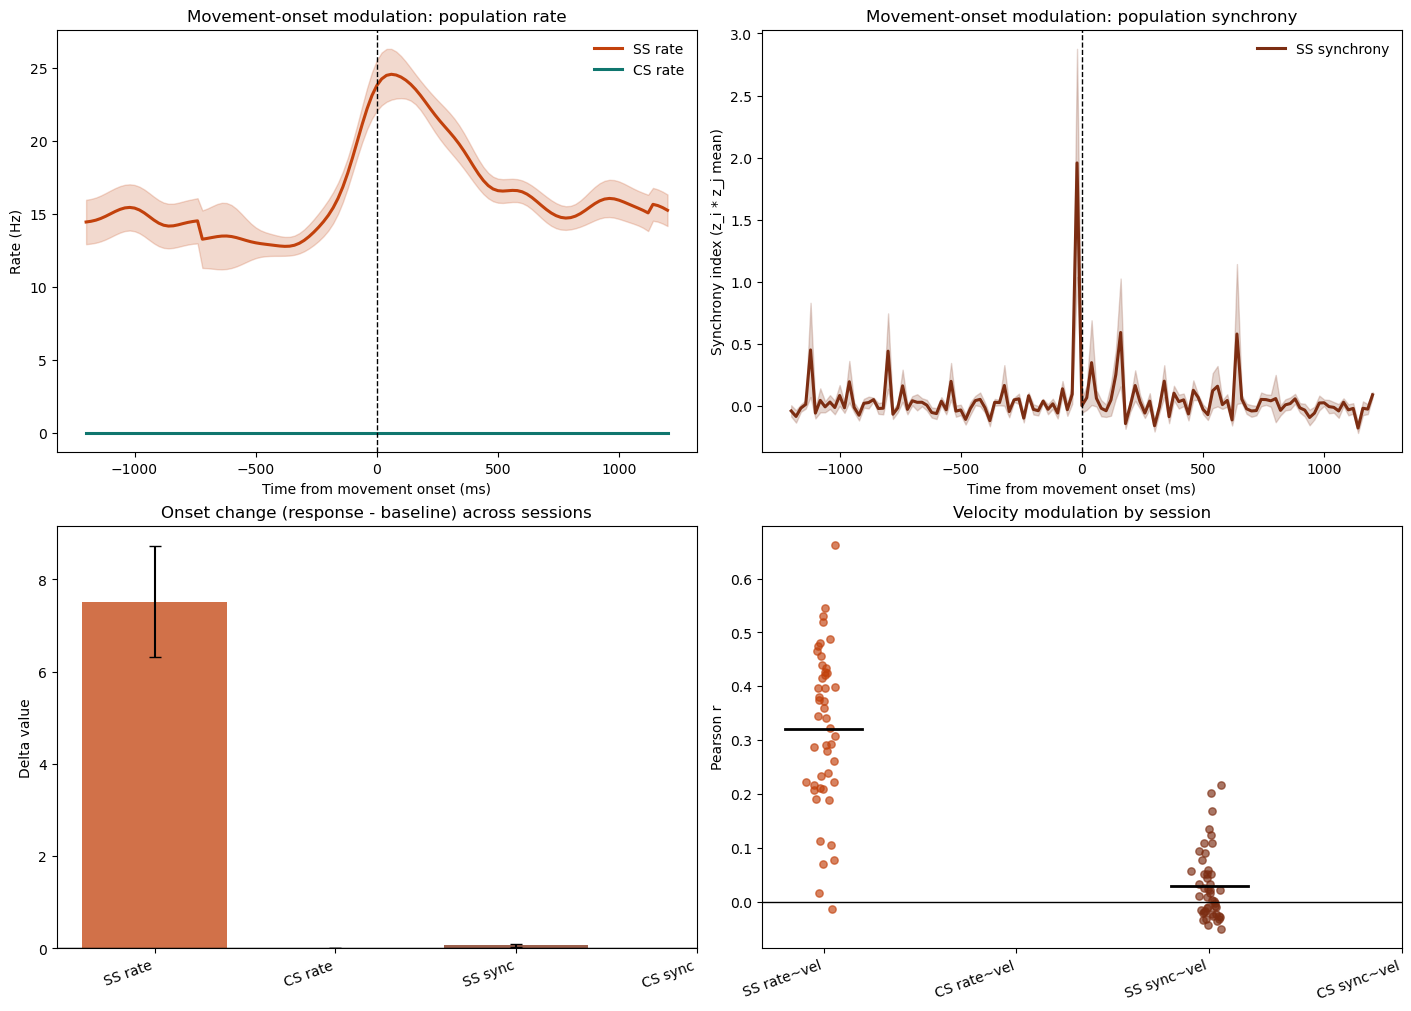


How pooled speed-vs-signal is computed:
1) Pool time samples from all matched sessions (after stride downsampling).
2) Bin speeds using method=quantile (count=14, max percentile=99).
3) Keep only bins with n >= 200 samples, then compute mean SS rate/synchrony (+SEM).
4) Apply rolling-median smoothing across 3 bins for display.


,speed_center_cm_s,n_samples,ss_rate_mean_hz,ss_rate_sem_hz,ss_sync_mean,ss_sync_sem,ss_rate_mean_hz_smooth,ss_sync_mean_smooth
0,0.000020,211791,12.868800,0.009787,0.038621,0.000845,14.390882,0.049866
1,0.240149,34082,15.912964,0.027352,0.061112,0.002665,15.912964,0.042558
2,0.480126,6546,18.067066,0.066397,0.042558,0.004946,17.707757,0.045722
3,0.719797,3022,17.707757,0.095920,0.045722,0.006129,17.707757,0.045722
4,0.960786,1562,17.588743,0.134997,0.074682,0.010684,17.707757,0.074682
5,1.200546,1004,17.981103,0.183370,0.128529,0.020684,17.811982,0.076476
6,1.440303,693,17.811982,0.214824,0.076476,0.017803,17.896543,0.102503


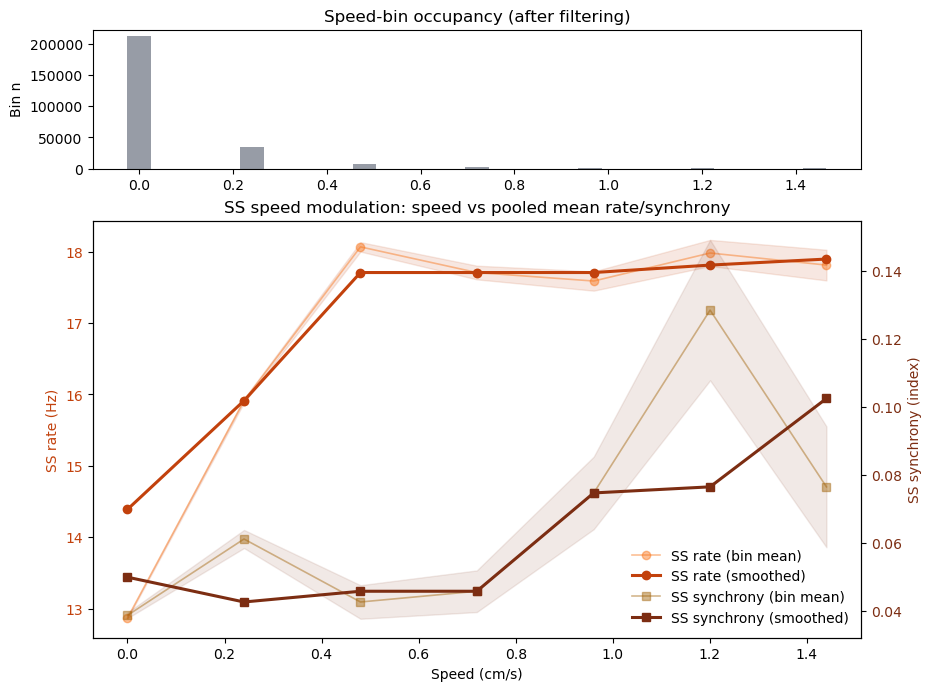


LOCOMOTION_ANALYSIS_DONE


In [18]:
# ---- Run movement-onset and velocity-modulation analysis ----

# Cell-4 runtime settings (kept at the beginning for transparency)
CELL4_SETTINGS = {
    'downsample_target_points_per_session': 3000,
    'speed_bin_method': 'quantile',      # 'quantile' or 'equal_width'
    'speed_bin_count': int(CONFIG['velocity_tuning_n_bins']),
    'speed_bin_max_speed_percentile': 99,
    'speed_bin_min_samples': 200,
    'speed_curve_smooth_bins': 3,
}

print('Cell 4 runtime settings:')
for k, v in CELL4_SETTINGS.items():
    print(f'  {k}: {v}')

session_table = build_session_table(MASTER_FOLDER)
print(f'\nTotal spike sessions: {len(session_table)}')
print(f'Matched behavior files: {int(session_table["matched"].sum())}')
display(session_table.head(12))

settings_note = globals().get(
    'SETTINGS_ANNOTATION',
    (
        f"Vel thr={CONFIG['movement_threshold_cm_s']} cm/s | rest>={CONFIG['min_rest_s']} s | run>={CONFIG['min_run_s']} s\n"
        f"Baseline={CONFIG['onset_baseline_ms']} ms | Response={CONFIG['onset_response_ms']} ms | "
        f"PETH={CONFIG['peth_window_ms']} ms step={CONFIG['peth_step_ms']} ms\n"
        f"SS smooth={CONFIG['ss_rate_smooth_ms']} ms, CS smooth={CONFIG['cs_rate_smooth_ms']} ms | "
        f"SS bin={CONFIG['ss_sync_bin_ms']} ms, CS bin={CONFIG['cs_sync_bin_ms']} ms"
    )
)
print('\nAnalysis settings:')
print(settings_note)

matched = session_table[session_table['matched']].copy()
if matched.empty:
    raise RuntimeError('No matched spike/behavior sessions. Check MASTER_FOLDER and naming rules.')

peth_grid_ms = np.arange(
    CONFIG['peth_window_ms'][0],
    CONFIG['peth_window_ms'][1] + CONFIG['peth_step_ms'],
    CONFIG['peth_step_ms'],
)

rows = []
ss_rate_peth = []
cs_rate_peth = []
ss_sync_peth = []
cs_sync_peth = []
vel_sample_rows = []

for rec in matched.itertuples(index=False):
    try:
        sp = load_spike_session(rec.spike_npz)
        beh_t_s, beh_vel = load_behavior_csv(rec.behavior_csv)
    except Exception as exc:
        print(f'Skip {rec.session_core}: load error -> {exc}')
        continue

    time_ms = sp['time_ms']
    time_s = time_ms / 1000.0
    vel = align_velocity_to_imaging(time_ms, beh_t_s, beh_vel)

    onset_idx = detect_movement_onsets(
        time_s,
        vel,
        threshold=CONFIG['movement_threshold_cm_s'],
        min_rest_s=CONFIG['min_rest_s'],
        min_run_s=CONFIG['min_run_s'],
    )
    onset_ms = time_ms[onset_idx] if len(onset_idx) else np.array([], dtype=float)

    # Population rate traces (mean across cells)
    ss_rate = population_rate_hz(sp['spike_times_ss'], time_ms, CONFIG['ss_rate_smooth_ms'])
    cs_rate = population_rate_hz(sp['spike_times_cs'], time_ms, CONFIG['cs_rate_smooth_ms'])

    # Population synchrony index traces
    ss_sync_t_s, ss_sync = population_sync_index(sp['spike_times_ss'], time_ms, CONFIG['ss_sync_bin_ms'])
    cs_sync_t_s, cs_sync = population_sync_index(sp['spike_times_cs'], time_ms, CONFIG['cs_sync_bin_ms'])

    # Interpolate synchrony to imaging timeline for velocity coupling
    ss_sync_on_img = np.interp(time_s, ss_sync_t_s, ss_sync, left=np.nan, right=np.nan) if len(ss_sync_t_s) else np.full_like(time_s, np.nan)
    cs_sync_on_img = np.interp(time_s, cs_sync_t_s, cs_sync, left=np.nan, right=np.nan) if len(cs_sync_t_s) else np.full_like(time_s, np.nan)

    # Movement-onset modulation (response - baseline)
    if len(onset_ms):
        ss_r_base = event_window_mean(time_ms, ss_rate, onset_ms, CONFIG['onset_baseline_ms'])
        ss_r_resp = event_window_mean(time_ms, ss_rate, onset_ms, CONFIG['onset_response_ms'])
        cs_r_base = event_window_mean(time_ms, cs_rate, onset_ms, CONFIG['onset_baseline_ms'])
        cs_r_resp = event_window_mean(time_ms, cs_rate, onset_ms, CONFIG['onset_response_ms'])

        ss_s_base = event_window_mean(time_s * 1000.0, ss_sync_on_img, onset_ms, CONFIG['onset_baseline_ms'])
        ss_s_resp = event_window_mean(time_s * 1000.0, ss_sync_on_img, onset_ms, CONFIG['onset_response_ms'])
        cs_s_base = event_window_mean(time_s * 1000.0, cs_sync_on_img, onset_ms, CONFIG['onset_baseline_ms'])
        cs_s_resp = event_window_mean(time_s * 1000.0, cs_sync_on_img, onset_ms, CONFIG['onset_response_ms'])

        ss_rate_delta = float(np.nanmean(ss_r_resp) - np.nanmean(ss_r_base)) if len(ss_r_base) and len(ss_r_resp) else np.nan
        cs_rate_delta = float(np.nanmean(cs_r_resp) - np.nanmean(cs_r_base)) if len(cs_r_base) and len(cs_r_resp) else np.nan
        ss_sync_delta = float(np.nanmean(ss_s_resp) - np.nanmean(ss_s_base)) if len(ss_s_base) and len(ss_s_resp) else np.nan
        cs_sync_delta = float(np.nanmean(cs_s_resp) - np.nanmean(cs_s_base)) if len(cs_s_base) and len(cs_s_resp) else np.nan

        # Build pooled onset-aligned traces
        for ev in onset_ms:
            ss_rate_peth.append(np.interp(ev + peth_grid_ms, time_ms, ss_rate, left=np.nan, right=np.nan))
            cs_rate_peth.append(np.interp(ev + peth_grid_ms, time_ms, cs_rate, left=np.nan, right=np.nan))

            if np.isfinite(ss_sync_on_img).any():
                ss_sync_peth.append(np.interp(ev + peth_grid_ms, time_ms, ss_sync_on_img, left=np.nan, right=np.nan))
            if np.isfinite(cs_sync_on_img).any():
                cs_sync_peth.append(np.interp(ev + peth_grid_ms, time_ms, cs_sync_on_img, left=np.nan, right=np.nan))
    else:
        ss_rate_delta = np.nan
        cs_rate_delta = np.nan
        ss_sync_delta = np.nan
        cs_sync_delta = np.nan

    # Velocity modulation (session-level Pearson r)
    ss_rate_vel_r = safe_pearson(vel, ss_rate)
    cs_rate_vel_r = safe_pearson(vel, cs_rate)
    ss_sync_vel_r = safe_pearson(vel, ss_sync_on_img)
    cs_sync_vel_r = safe_pearson(vel, cs_sync_on_img)

    # Sample rows for pooled velocity analyses
    stride = max(1, len(time_ms) // int(CELL4_SETTINGS['downsample_target_points_per_session']))
    idx = np.arange(0, len(time_ms), stride)
    vel_sample_rows.append(pd.DataFrame({
        'session': rec.session_core,
        'velocity_cm_s': vel[idx],
        'ss_rate_hz': ss_rate[idx],
        'cs_rate_hz': cs_rate[idx],
        'ss_sync': ss_sync_on_img[idx],
        'cs_sync': cs_sync_on_img[idx],
    }))

    rows.append({
        'session': rec.session_core,
        'n_cells': len(sp['cell_names']),
        'n_onsets': int(len(onset_ms)),
        'ss_rate_delta_hz': ss_rate_delta,
        'cs_rate_delta_hz': cs_rate_delta,
        'ss_sync_delta': ss_sync_delta,
        'cs_sync_delta': cs_sync_delta,
        'ss_rate_vs_vel_r': ss_rate_vel_r,
        'cs_rate_vs_vel_r': cs_rate_vel_r,
        'ss_sync_vs_vel_r': ss_sync_vel_r,
        'cs_sync_vs_vel_r': cs_sync_vel_r,
    })

loco_session_summary_df = pd.DataFrame(rows).sort_values('session').reset_index(drop=True)
loco_velocity_samples_df = pd.concat(vel_sample_rows, ignore_index=True) if vel_sample_rows else pd.DataFrame()

print('\nSession-level summary:')
display(loco_session_summary_df)

# ---- Plot summary panels ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

# Panel 1: movement-onset PETH for rate
ax = axes[0, 0]
if len(ss_rate_peth):
    arr = np.vstack(ss_rate_peth)
    m = np.nanmean(arr, axis=0)
    s = np.nanstd(arr, axis=0) / np.sqrt(max(arr.shape[0], 1))
    ax.plot(peth_grid_ms, m, color='#C2410C', lw=2.2, label='SS rate')
    ax.fill_between(peth_grid_ms, m - s, m + s, color='#C2410C', alpha=0.2)
if len(cs_rate_peth):
    arr = np.vstack(cs_rate_peth)
    m = np.nanmean(arr, axis=0)
    s = np.nanstd(arr, axis=0) / np.sqrt(max(arr.shape[0], 1))
    ax.plot(peth_grid_ms, m, color='#0F766E', lw=2.2, label='CS rate')
    ax.fill_between(peth_grid_ms, m - s, m + s, color='#0F766E', alpha=0.2)
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_title('Movement-onset modulation: population rate')
ax.set_xlabel('Time from movement onset (ms)')
ax.set_ylabel('Rate (Hz)')
ax.legend(frameon=False)

# Panel 2: movement-onset PETH for synchrony
ax = axes[0, 1]
if len(ss_sync_peth):
    arr = np.vstack(ss_sync_peth)
    m = np.nanmean(arr, axis=0)
    s = np.nanstd(arr, axis=0) / np.sqrt(max(arr.shape[0], 1))
    ax.plot(peth_grid_ms, m, color='#7C2D12', lw=2.2, label='SS synchrony')
    ax.fill_between(peth_grid_ms, m - s, m + s, color='#7C2D12', alpha=0.2)
if len(cs_sync_peth):
    arr = np.vstack(cs_sync_peth)
    m = np.nanmean(arr, axis=0)
    s = np.nanstd(arr, axis=0) / np.sqrt(max(arr.shape[0], 1))
    ax.plot(peth_grid_ms, m, color='#115E59', lw=2.2, label='CS synchrony')
    ax.fill_between(peth_grid_ms, m - s, m + s, color='#115E59', alpha=0.2)
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_title('Movement-onset modulation: population synchrony')
ax.set_xlabel('Time from movement onset (ms)')
ax.set_ylabel('Synchrony index (z_i * z_j mean)')
ax.legend(frameon=False)

# Panel 3: session-level onset delta summary
ax = axes[1, 0]
labels = ['SS rate', 'CS rate', 'SS sync', 'CS sync']
cols = ['ss_rate_delta_hz', 'cs_rate_delta_hz', 'ss_sync_delta', 'cs_sync_delta']
colors = ['#C2410C', '#0F766E', '#7C2D12', '#115E59']
means = [np.nanmean(loco_session_summary_df[c]) for c in cols]
sems = [np.nanstd(loco_session_summary_df[c]) / np.sqrt(max(np.isfinite(loco_session_summary_df[c]).sum(), 1)) for c in cols]
xx = np.arange(len(labels))
ax.bar(xx, means, yerr=sems, color=colors, alpha=0.75, capsize=4)
ax.axhline(0, color='k', lw=1)
ax.set_xticks(xx)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_title('Onset change (response - baseline) across sessions')
ax.set_ylabel('Delta value')

# Panel 4: velocity modulation summary (session-level correlations)
ax = axes[1, 1]
rate_cols = ['ss_rate_vs_vel_r', 'cs_rate_vs_vel_r']
sync_cols = ['ss_sync_vs_vel_r', 'cs_sync_vs_vel_r']
all_cols = rate_cols + sync_cols
all_labels = ['SS rate~vel', 'CS rate~vel', 'SS sync~vel', 'CS sync~vel']
all_colors = ['#C2410C', '#0F766E', '#7C2D12', '#115E59']

for k, (c, lab, col) in enumerate(zip(all_cols, all_labels, all_colors)):
    y = pd.to_numeric(loco_session_summary_df[c], errors='coerce').to_numpy(dtype=float)
    y = y[np.isfinite(y)]
    if len(y) == 0:
        continue
    jitter = np.random.default_rng(0).normal(0, 0.04, size=len(y))
    ax.scatter(np.full(len(y), k) + jitter, y, s=28, color=col, alpha=0.65)
    ax.plot([k - 0.2, k + 0.2], [np.mean(y), np.mean(y)], color='black', lw=2)

ax.axhline(0, color='k', lw=1)
ax.set_xticks(np.arange(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=20, ha='right')
ax.set_ylabel('Pearson r')
ax.set_title('Velocity modulation by session')

plt.show()

# ---- SS speed modulation as speed (x) vs pooled mean rate/synchrony (y) ----
if not loco_velocity_samples_df.empty:
    tmp = loco_velocity_samples_df.copy()
    tmp['velocity_cm_s'] = pd.to_numeric(tmp['velocity_cm_s'], errors='coerce')
    tmp['ss_rate_hz'] = pd.to_numeric(tmp['ss_rate_hz'], errors='coerce')
    tmp['ss_sync'] = pd.to_numeric(tmp['ss_sync'], errors='coerce')

    valid = np.isfinite(tmp['velocity_cm_s'])
    tmp = tmp.loc[valid].copy()

    if not tmp.empty:
        vmax = np.nanpercentile(tmp['velocity_cm_s'], float(CELL4_SETTINGS['speed_bin_max_speed_percentile']))
        n_bins = int(CELL4_SETTINGS['speed_bin_count'])
        if np.isfinite(vmax) and vmax > 0 and n_bins >= 3:
            if CELL4_SETTINGS['speed_bin_method'] == 'quantile':
                q = np.linspace(0.0, 1.0, n_bins + 1)
                edges = np.unique(np.nanquantile(tmp['velocity_cm_s'].to_numpy(dtype=float), q))
                if len(edges) < 4:
                    edges = np.linspace(0.0, vmax, n_bins + 1)
            else:
                edges = np.linspace(0.0, vmax, n_bins + 1)

            tmp['vel_bin'] = pd.cut(tmp['velocity_cm_s'], bins=edges, include_lowest=True, duplicates='drop')

            pooled_speed_rows = []
            for iv in tmp['vel_bin'].dropna().unique():
                sub = tmp[tmp['vel_bin'] == iv].copy()
                ss_rate_vals = sub['ss_rate_hz'].to_numpy(dtype=float)
                ss_sync_vals = sub['ss_sync'].to_numpy(dtype=float)

                n_sub = len(sub)
                ss_rate_mean = float(np.nanmean(ss_rate_vals)) if n_sub > 0 else np.nan
                ss_sync_mean = float(np.nanmean(ss_sync_vals)) if n_sub > 0 else np.nan
                ss_rate_sem = float(np.nanstd(ss_rate_vals) / np.sqrt(n_sub)) if n_sub > 1 else np.nan
                ss_sync_sem = float(np.nanstd(ss_sync_vals) / np.sqrt(n_sub)) if n_sub > 1 else np.nan

                pooled_speed_rows.append({
                    'speed_center_cm_s': float(np.nanmean(sub['velocity_cm_s'].to_numpy(dtype=float))),
                    'n_samples': int(n_sub),
                    'ss_rate_mean_hz': ss_rate_mean,
                    'ss_rate_sem_hz': ss_rate_sem,
                    'ss_sync_mean': ss_sync_mean,
                    'ss_sync_sem': ss_sync_sem,
                })

            pooled_speed_signal_df = pd.DataFrame(pooled_speed_rows).sort_values('speed_center_cm_s')

            min_n = int(CELL4_SETTINGS['speed_bin_min_samples'])
            pooled_speed_signal_df = pooled_speed_signal_df[pooled_speed_signal_df['n_samples'] >= min_n].copy()
            pooled_speed_signal_df = pooled_speed_signal_df.sort_values('speed_center_cm_s').reset_index(drop=True)

            # Smooth over neighboring bins to reduce bin-to-bin noise.
            smooth_k = max(1, int(CELL4_SETTINGS['speed_curve_smooth_bins']))
            pooled_speed_signal_df['ss_rate_mean_hz_smooth'] = (
                pooled_speed_signal_df['ss_rate_mean_hz'].rolling(window=smooth_k, center=True, min_periods=1).median()
            )
            pooled_speed_signal_df['ss_sync_mean_smooth'] = (
                pooled_speed_signal_df['ss_sync_mean'].rolling(window=smooth_k, center=True, min_periods=1).median()
            )

            print('\nHow pooled speed-vs-signal is computed:')
            print('1) Pool time samples from all matched sessions (after stride downsampling).')
            print(f"2) Bin speeds using method={CELL4_SETTINGS['speed_bin_method']} (count={n_bins}, max percentile={CELL4_SETTINGS['speed_bin_max_speed_percentile']}).")
            print(f"3) Keep only bins with n >= {min_n} samples, then compute mean SS rate/synchrony (+SEM).")
            print(f"4) Apply rolling-median smoothing across {smooth_k} bins for display.")
            display(pooled_speed_signal_df)

            fig, (ax_occ, ax1) = plt.subplots(
                2,
                1,
                figsize=(9.2, 6.8),
                constrained_layout=True,
                gridspec_kw={'height_ratios': [1.0, 3.0]},
            )

            x = pooled_speed_signal_df['speed_center_cm_s'].to_numpy(dtype=float)

            # Occupancy panel helps interpret reliability of each speed bin.
            ax_occ.bar(x, pooled_speed_signal_df['n_samples'].to_numpy(dtype=float), width=0.05, color='#6B7280', alpha=0.7)
            ax_occ.set_ylabel('Bin n')
            ax_occ.set_title('Speed-bin occupancy (after filtering)')

            y_rate = pooled_speed_signal_df['ss_rate_mean_hz'].to_numpy(dtype=float)
            y_rate_s = pooled_speed_signal_df['ss_rate_mean_hz_smooth'].to_numpy(dtype=float)
            e_rate = pooled_speed_signal_df['ss_rate_sem_hz'].to_numpy(dtype=float)

            ax1.plot(x, y_rate, color='#F97316', marker='o', lw=1.2, alpha=0.45, label='SS rate (bin mean)')
            ax1.plot(x, y_rate_s, color='#C2410C', marker='o', lw=2.2, label='SS rate (smoothed)')
            if np.isfinite(e_rate).any():
                ax1.fill_between(x, y_rate - e_rate, y_rate + e_rate, color='#C2410C', alpha=0.12)
            ax1.set_xlabel('Speed (cm/s)')
            ax1.set_ylabel('SS rate (Hz)', color='#C2410C')
            ax1.tick_params(axis='y', labelcolor='#C2410C')

            ax2 = ax1.twinx()
            y_sync = pooled_speed_signal_df['ss_sync_mean'].to_numpy(dtype=float)
            y_sync_s = pooled_speed_signal_df['ss_sync_mean_smooth'].to_numpy(dtype=float)
            e_sync = pooled_speed_signal_df['ss_sync_sem'].to_numpy(dtype=float)
            ax2.plot(x, y_sync, color='#A16207', marker='s', lw=1.2, alpha=0.45, label='SS synchrony (bin mean)')
            ax2.plot(x, y_sync_s, color='#7C2D12', marker='s', lw=2.2, label='SS synchrony (smoothed)')
            if np.isfinite(e_sync).any():
                ax2.fill_between(x, y_sync - e_sync, y_sync + e_sync, color='#7C2D12', alpha=0.10)
            ax2.set_ylabel('SS synchrony (index)', color='#7C2D12')
            ax2.tick_params(axis='y', labelcolor='#7C2D12')

            lines = ax1.get_lines() + ax2.get_lines()
            labels = [ln.get_label() for ln in lines]
            ax1.legend(lines, labels, frameon=False, loc='best')
            ax1.set_title('SS speed modulation: speed vs pooled mean rate/synchrony')
            plt.show()

print('\nLOCOMOTION_ANALYSIS_DONE')

## Notes

- This notebook expects a master folder with:
  - `spike_detection/*_analyzed.npz`
  - `behavior/*.csv`
- Behavior velocity is read from `Smoothed_Vel_cm_s`.
- Movement onsets are detected from threshold crossing after a rest period.
- Outputs include:
  - SS/CS rate and synchrony changes at movement onset
  - SS/CS rate and synchrony modulation by velocity
- To analyze a different dataset, change `MASTER_FOLDER` in Cell 1 and rerun Cell 2.